In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, GlobalMaxPooling2D, Concatenate, BatchNormalization, Conv2D, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# Mengecek direktori saat ini
current_dir = os.getcwd()
print("Direktori awal:", current_dir)

# Jika masih di dalam folder 'notebooks', naik satu tingkat ke folder root proyek
if current_dir.endswith("notebooks"):
    os.chdir("..")
    print("Direktori setelah disesuaikan:", os.getcwd())


Direktori awal: d:\pokemon-tcg-classification\notebooks
Direktori setelah disesuaikan: d:\pokemon-tcg-classification


In [3]:
# ==========================================
# 1. KONFIGURASI PARAMETER & DIREKTORI
# ==========================================
TRAIN_DIR = os.path.join("data", "processed", "train")
VAL_DIR = os.path.join("data", "processed", "val")

# Berdasarkan batasan: Resize 300x420 (width, height)
# Dalam Keras, format target_size adalah (height, width)
IMG_HEIGHT = 420
IMG_WIDTH = 300
BATCH_SIZE = 16
NUM_CLASSES = 10


In [4]:
# ==========================================
# 2. PRA-PEMROSESAN & AUGMENTASI DATA (UPDATE)
# ==========================================
print("Menyiapkan Data Generator...")

# Augmentasi diubah agar lebih "aman" untuk citra kartu yang memiliki teks/simbol di sudut
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,           # Dikurangi dari 20 agar sudut kartu tidak terpotong parah
    brightness_range=[0.9, 1.1],# Variasi pencahayaan ringan
    zoom_range=0.05,            # Sangat kecil, sekadar simulasi jarak foto
    horizontal_flip=False,      # PENTING: Dibuat False agar teks & simbol tidak terbalik
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Mengambil semua label kelas dari data latih
train_classes = train_generator.classes

# Menghitung bobot secara otomatis
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)

# Konversi ke dictionary agar bisa dibaca oleh Keras
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights yang akan digunakan:", class_weight_dict)


Menyiapkan Data Generator...
Found 1605 images belonging to 10 classes.
Found 340 images belonging to 10 classes.
Class Weights yang akan digunakan: {0: np.float64(1.1145833333333333), 1: np.float64(0.9441176470588235), 2: np.float64(0.9786585365853658), 3: np.float64(1.2067669172932332), 4: np.float64(0.9331395348837209), 5: np.float64(0.823076923076923), 6: np.float64(0.9385964912280702), 7: np.float64(1.284), 8: np.float64(1.0354838709677419), 9: np.float64(0.9119318181818182)}


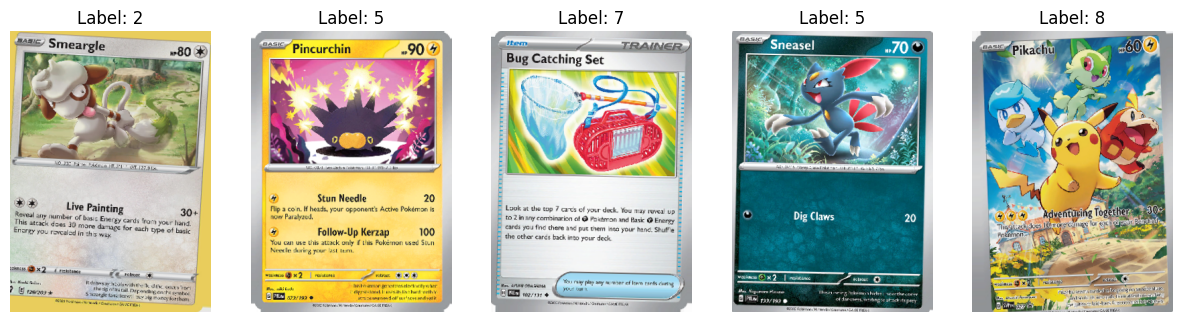

In [5]:
# Mengambil satu batch data latih
x_batch, y_batch = next(train_generator)

# Menampilkan 5 gambar pertama dari batch tersebut
plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(x_batch[i])
    plt.title(f"Label: {y_batch[i].argmax()}")
    plt.axis("off")
plt.show()


In [6]:
print("Membangun Arsitektur dengan Spatial Attention...")

base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# TAHAP 1: FEATURE EXTRACTION
base_model.trainable = False 

x = base_model.output

# --- OPSI 1: SPATIAL ATTENTION MECHANISM ---
# Lapisan ini membuat "peta panas" (heatmap) untuk mencari lokasi fitur penting
attention = Conv2D(1, (1, 1), padding='same', activation='sigmoid', name='spatial_attention')(x)
x = Multiply()([x, attention]) # Mengalikan fitur asli dengan peta perhatian
# -------------------------------------------

# Multi-Pooling 
avg_pool = GlobalAveragePooling2D()(x)
max_pool = GlobalMaxPooling2D()(x)
x = Concatenate()([avg_pool, max_pool])

# Classifier Layers
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# --- OPSI 3: MENGGUNAKAN RMSPROP ---
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001, momentum=0.9),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)


Membangun Arsitektur dengan Spatial Attention...


C:\Users\aryay\AppData\Local\Temp\ipykernel_6540\832873391.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [7]:
print("\n=== Memulai Tahap 1: Feature Extraction ===")
history_phase1 = model.fit(
    train_generator,
    epochs=10, 
    validation_data=val_generator,
    class_weight=class_weight_dict
)



=== Memulai Tahap 1: Feature Extraction ===
Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.2019 - loss: 11.9615 - val_accuracy: 0.1441 - val_loss: 9.0551
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.2125 - loss: 8.0926 - val_accuracy: 0.2441 - val_loss: 7.4040
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.2424 - loss: 7.0385 - val_accuracy: 0.2647 - val_loss: 6.5314
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.2442 - loss: 6.2337 - val_accuracy: 0.2353 - val_loss: 5.8578
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.2380 - loss: 5.5323 - val_accuracy: 0.2559 - val_loss: 5.2019
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.2561 - loss: 5.1192 - val_accuracy: 0.1853 - val_loss: 4.9322
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.2374 - loss: 4.8487 - val_accuracy: 0.2412 - val_loss: 4.6252
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/ste

In [8]:
# TAHAP 2: FINE-TUNING (Membekukan 75% layer awal sesuai batasan)
print("\n=== Memulai Tahap 2: Fine-Tuning ===")
base_model.trainable = True

freeze_until = int(len(base_model.layers) * 0.75)
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

# Menggunakan RMSprop dengan learning rate yang sangat kecil
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-5, momentum=0.9),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

history_phase2 = model.fit(
    train_generator,
    epochs=30, 
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)



=== Memulai Tahap 2: Fine-Tuning ===
Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.2212 - loss: 4.2888 - val_accuracy: 0.2412 - val_loss: 4.0092 - learning_rate: 1.0000e-05
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.2972 - loss: 3.7076 - val_accuracy: 0.2000 - val_loss: 4.1965 - learning_rate: 1.0000e-05
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.3433 - loss: 3.3794 - val_accuracy: 0.1824 - val_loss: 4.9924 - learning_rate: 1.0000e-05
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3649 - loss: 3.1649
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
101/101 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.3583 - loss: 3.1309 - val_accuracy: 0.1353 - val_loss: 4.5876 - learning_rate: 1.0000e-05
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.3907 - loss: 2.9466 - val_accuracy: 0.1235 - val_loss: 4.2285 - learning_rate: 5.0000e-06
Epoch 6/30
101/101 ━━━━━━━━

In [9]:
# Menyimpan model yang sudah dilatih ke folder models/
model_path = os.path.join('models', 'mobilenetv2_pokemon_tcg.keras')
model.save(model_path)
print(f"Model berhasil disimpan di: {model_path}")


Model berhasil disimpan di: models\mobilenetv2_pokemon_tcg.keras


In [10]:
# ==========================================
# 4. EVALUASI MODEL PADA DATA UJI (TEST SET)
# ==========================================
TEST_DIR = os.path.join('data', 'processed', 'test')

# Hanya normalisasi, tanpa augmentasi
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # PENTING: Jangan diacak agar y_true dan y_pred sejajar
)

# Menghitung Akurasi dan Loss dasar
print("Mengevaluasi model...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nAkurasi pada Test Set: {test_acc * 100:.2f}%")
print(f"Loss pada Test Set: {test_loss:.4f}")


Found 355 images belonging to 10 classes.
Mengevaluasi model...
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 916ms/step - accuracy: 0.4761 - loss: 2.2527

Akurasi pada Test Set: 47.61%
Loss pada Test Set: 2.2527


Melakukan prediksi pada Test Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 700ms/step

=== Laporan Klasifikasi (Classification Report) ===


d:\pokemon-tcg-classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\pokemon-tcg-classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\pokemon-tcg-classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

                       precision    recall  f1-score   support

                  151       0.00      0.00      0.00        32
      destined-rivals       0.51      0.68      0.58        38
       evolving-skies       0.69      0.56      0.62        36
     journey-together       0.67      0.28      0.39        29
          lost-origin       0.67      0.76      0.72        38
       paldea-evolved       0.37      0.63      0.47        43
        paldean-fates       0.83      0.53      0.65        38
 prismatic-evolutions       0.24      0.61      0.34        28
scarlet-violet-promos       0.50      0.44      0.47        34
       surging-sparks       0.32      0.18      0.23        39

             accuracy                           0.48       355
            macro avg       0.48      0.47      0.45       355
         weighted avg       0.49      0.48      0.46       355

Confusion Matrix berhasil disimpan di: reports\confusion_matrix_mobilenet.png


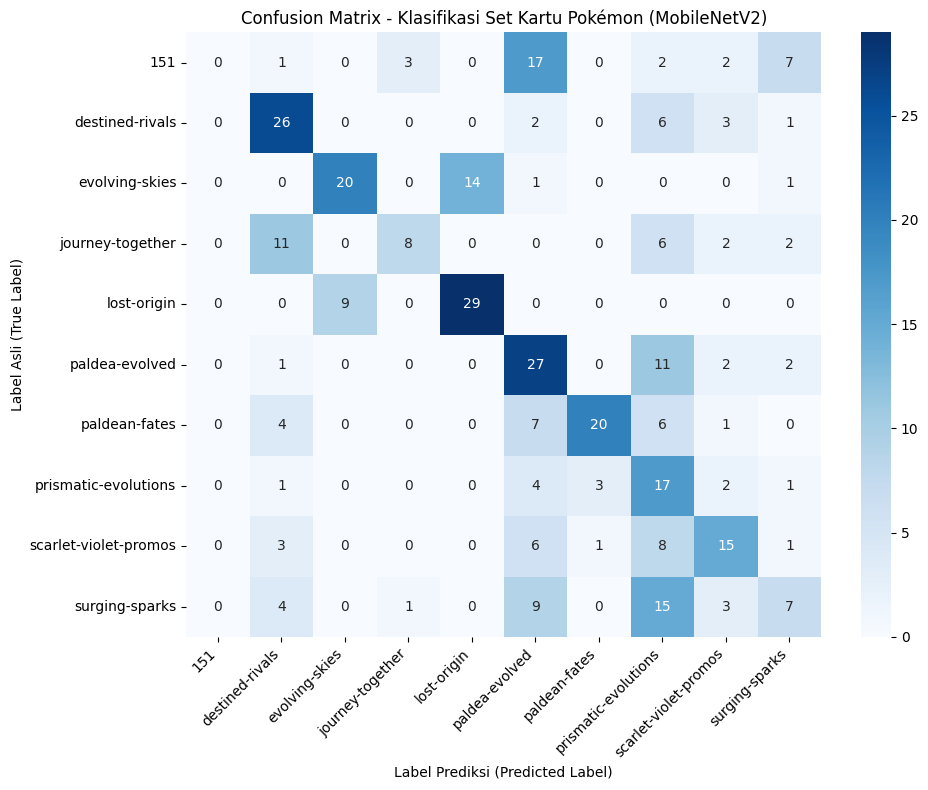

In [11]:
print("Melakukan prediksi pada Test Set...")
# Mendapatkan probabilitas prediksi
predictions = model.predict(test_generator)

# Mengambil indeks kelas dengan probabilitas tertinggi (argmax)
y_pred = np.argmax(predictions, axis=1)

# Mengambil label asli dari generator
y_true = test_generator.classes

# Mengambil nama-nama kelas (10 Set Pokémon)
class_names = list(test_generator.class_indices.keys())

# 1. Classification Report (Precision, Recall, F1-Score)
print("\n=== Laporan Klasifikasi (Classification Report) ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Klasifikasi Set Kartu Pokémon (MobileNetV2)')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Label Prediksi (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Menyimpan gambar Confusion Matrix ke folder reports (opsional tapi disarankan untuk skripsi)
cm_path = os.path.join('reports', 'confusion_matrix_mobilenet.png')
# Pastikan folder reports ada
os.makedirs('reports', exist_ok=True)
plt.savefig(cm_path)
print(f"Confusion Matrix berhasil disimpan di: {cm_path}")

plt.show()


Menghasilkan Learning Curves...
Learning Curves berhasil disimpan di: reports\learning_curves_mobilenet.png


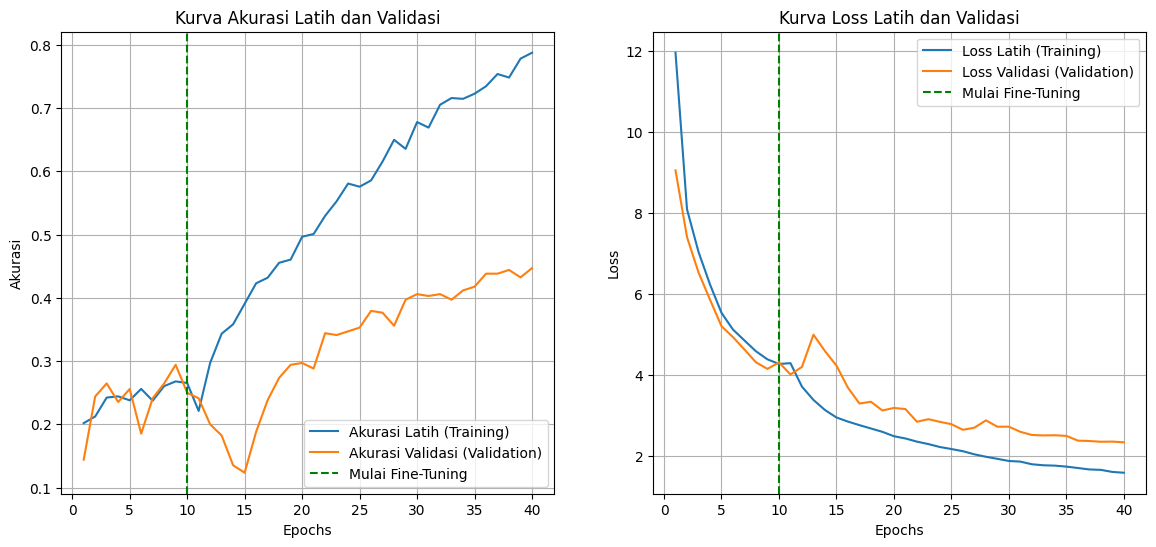

In [12]:
# ==========================================
# 5. VISUALISASI LEARNING CURVES
# ==========================================
print("Menghasilkan Learning Curves...")

# Menggabungkan data metrik dari Tahap 1 (Feature Extraction) dan Tahap 2 (Fine-Tuning)
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

# Menentukan titik transisi fine-tuning
initial_epochs = len(history_phase1.history['accuracy'])
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# 1. Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Latih (Training)')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi (Validation)')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Akurasi Latih dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Latih (Training)')
plt.plot(epochs_range, val_loss, label='Loss Validasi (Validation)')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Loss Latih dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Menyimpan grafik ke folder reports
lc_path = os.path.join('reports', 'learning_curves_mobilenet.png')
plt.savefig(lc_path)
print(f"Learning Curves berhasil disimpan di: {lc_path}")

plt.show()
